In [1346]:
from importlib import reload
import sys
import subprocess
import copy

import scipy
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../python")
import pymodelica
reload(pymodelica)


<module 'pymodelica' from '/mnt/c/Users/Tom/Documents/ThermalModel/python/pymodelica.py'>

# Run the simualtion

pymodelica.run_model() is a wrapper to do a two-step simulation. First, a fast simulation to reach equilibrium. The model is linearized around the equilibrium point. the equilibrium point is also used to initialize a second simulation with fine steps to get a non-linear impulse response.

-overrideFile=C:/Users/Tom/Documents/ThermalModel/parameters/params_lmo_v1_mod_absorber.txt

In [1437]:
MODEL_EXE_NAME = "System_LMO_exe"
MODEL_FILE = "../System_LMO.mo"
MODEL_BUILD_DIR = "../build"
MODEL_FILE_LIN = f"linearized_model.py"
MODEL_RESULT = f'{MODEL_BUILD_DIR}/{MODEL_EXE_NAME}_res_init.mat'


OVERRIDE_PARAMS = "../parameters/params_lmo_v1_mod_absorber.txt"
EQUILIBRIUM_TIME = 20.0
EQUILIBRIUM_STEP = 2e-3
FINE_STOP_TIME = 0.2
FINE_STEP_SIZE = 3e-6
TOLERANCE = 0.1e-8
PULSE_ENERGY_EV = 200

CINDEX_TARGET = 10
CINDEX_TARGETGOLD = 2


In [1438]:
run_info = pymodelica.run_model(
    model_exe = MODEL_EXE_NAME,
    build_dir = MODEL_BUILD_DIR,
    override_file = OVERRIDE_PARAMS,
    params={"Edep": PULSE_ENERGY_EV},
    equilibrium_time=EQUILIBRIUM_TIME,
    coarse_step_size=EQUILIBRIUM_STEP,
    fine_stop_time=FINE_STOP_TIME,
    fine_step_size=FINE_STEP_SIZE,
    tolerance=TOLERANCE,
    solver="dassl",
    linearized_model_file=MODEL_FILE_LIN,
    init_result_file=None,
    pulse_result_file=None,
    keep_runs=True,
    extra_coarse_args=None,
    extra_fine_args=None,
)

print(run_info)
config = pymodelica.read_config(run_info["override_file"])

Runing coarse simulation
Runing fine simulation
{'run_dir': PosixPath('/mnt/c/Users/Tom/Documents/ThermalModel/build'), 'override_file': PosixPath('/mnt/c/Users/Tom/Documents/ThermalModel/build/params_lmo_v1_mod_absorber_mcmc_override.txt'), 'init_result': PosixPath('/mnt/c/Users/Tom/Documents/ThermalModel/build/System_LMO_exe_res_init.mat'), 'pulse_result': PosixPath('/mnt/c/Users/Tom/Documents/ThermalModel/build/System_LMO_exe_res_final.mat'), 'linearized_model': PosixPath('/mnt/c/Users/Tom/Documents/ThermalModel/build/linearized_model.py'), 'logs': {'coarse': CompletedProcess(args=['./System_LMO_exe', '-overrideFile=params_lmo_v1_mod_absorber_mcmc_override.txt', '-startTime=0', '-stopTime=20.0', '-stepSize=0.002', '-tolerance=1e-09', '-s=dassl', '-w', '-outputFormat=mat', '-r=System_LMO_exe_res_init.mat', '-l=20.0'], returncode=0, stdout='LOG_STDOUT        | warning | You are overriding Bias_C with a small value or zero.\n|                 | |       | This could lead to numerically 

dict_keys(['CL.v', 'L.i', 'c1.T', 'c10.T', 'c2.T', 'c3.T', 'c4.T', 'c5.T', 'c6.T', 'c7.T', 'c8.T', 'c9.T', 'der(CL.v)', 'der(L.i)', 'der(c1.T)', 'der(c10.T)', 'der(c2.T)', 'der(c3.T)', 'der(c4.T)', 'der(c5.T)', 'der(c6.T)', 'der(c7.T)', 'der(c8.T)', 'der(c9.T)', 'C1', 'C10', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'CL.i', 'G1', 'G10', 'G11', 'G12', 'G13', 'G14', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'GND.p.i', 'GND.p.v', 'HeatSource.port.Q_flow', 'HeatSource1.port.Q_flow', 'L.v', 'RL.LossPower', 'RL.R_actual', 'RL.i', 'Rp.LossPower', 'Rp.R_actual', 'Rp.n.v', 'Rp.v', 'c1.P_Joule', 'c1.R', 'c1.cp', 'c1.heatPort.Q_flow', 'c1.v', 'c10.cp', 'c10.port.Q_flow', 'c2.cp', 'c2.port.Q_flow', 'c3.cp', 'c3.port.Q_flow', 'c4.cp', 'c4.port.Q_flow', 'c5.cp', 'c5.port.Q_flow', 'c6.cp', 'c6.port.Q_flow', 'c7.cp', 'c7.port.Q_flow', 'c8.cp', 'c8.port.Q_flow', 'c9.cp', 'c9.port.Q_flow', 'edep_film.y', 'edep_target.y', 'fixedTemperature.port.Q_flow', 'g1.Q_flow', 'g10.Q_flow', 'g11.Q_flow'

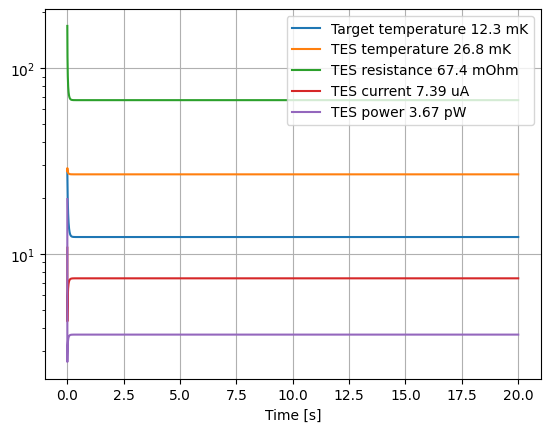

In [1439]:
# Load simulation result
time_steps_init, data_init = pymodelica.load(run_info["init_result"])

time_steps, data = pymodelica.load(run_info["pulse_result"])
print(data.keys())


# Plot all C and G to check if the system is at equilibrium
y = data_init['T10']*1e3
plt.plot(time_steps_init, y, label=f"Target temperature {y[-1]:.3g} mK")
y = data_init['T1']*1e3
plt.plot(time_steps_init, y, label=f"TES temperature {y[-1]:.3g} mK")
y = data_init['c1.R']*1e3
plt.plot(time_steps_init, y, label=f"TES resistance {y[-1]:.3g} mOhm")
y = data_init['c1.i']*1e6
plt.plot(time_steps_init, y, label=f"TES current {y[-1]:.3g} uA")
y = data_init['c1.i']**2*data_init['c1.R']*1e12
plt.plot(time_steps_init, y, label=f"TES power {y[-1]:.3g} pW")
plt.legend()
plt.xlabel("Time [s]")
plt.grid()
plt.yscale("log")


In [1440]:
# Annotate SVG image with simulation result
pymodelica.mod_svg("../System_LMO.svg", "temp_image.svg", data_init, system_name="System_LMO", width=1200, display=True)

## Pulse, Noise and Complex impedance

In [1441]:
model = pymodelica.TESModel(f"{MODEL_BUILD_DIR}/{MODEL_FILE_LIN}", 
                 MODEL_FILE, 
                 MODEL_RESULT,
                 config = {},
                 f_min = 1, f_max = 1000e3, points = 1000)

frequencies, noise_current = model.get_noise(
    Rsh_temperature = 0.2,
    # Rp_temperature = 0.2,
    noise_electronics = 4.2e-12,
    noise_flicker_corner = 20,
    noise_flicker_gamma = 1,
    index_cinput = CINDEX_TARGET)

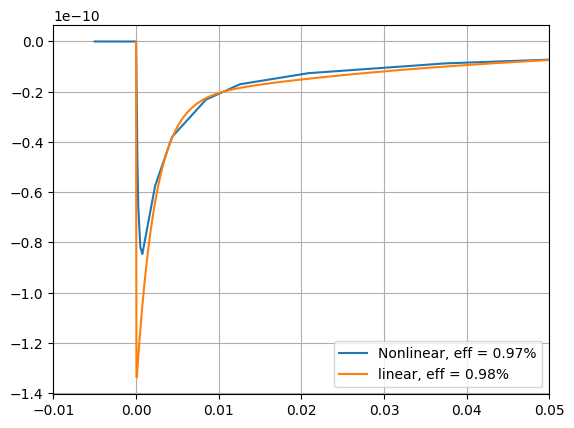

180.48925254817698
Target referred resolution[eV]: 925.6732757661142
Input referred resolution[eV]: 316.5201653845957
Input referred resolution(nonlinear)[eV]: 180.48925254817698


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: xlabel='Frequency [Hz]', ylabel='|$Z_{circ}$| [$\\Omega$]'>,
        <Axes: xlabel='Real($Z_{circ}$) [$\\Omega$]', ylabel='Imag($Z_{circ}$) [$\\Omega$]'>],
       dtype=object))

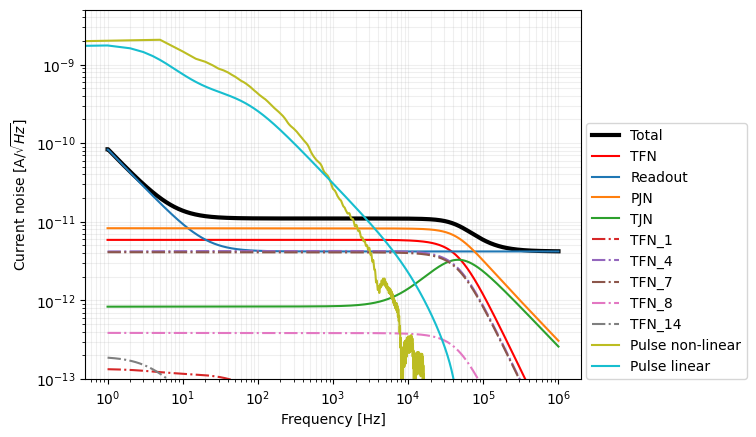

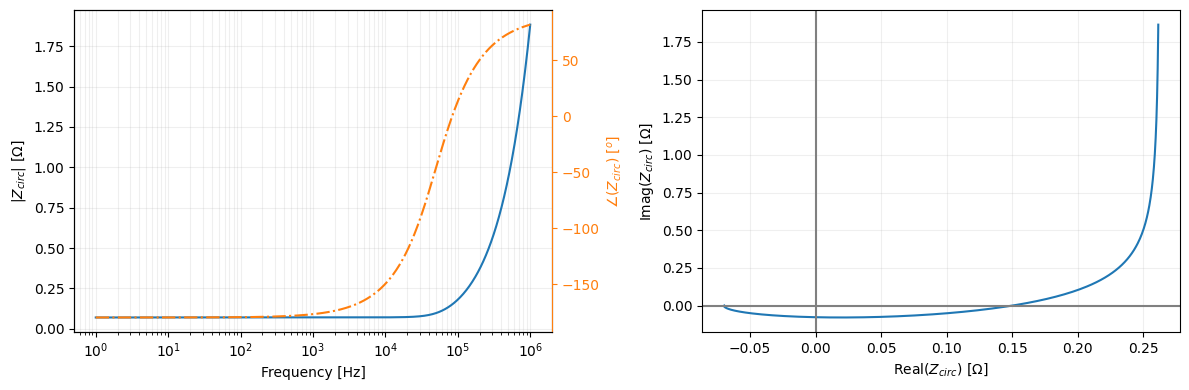

In [1442]:
# Impulse response
t_linear, y_linear = model.get_impulse_split(index_cinput1 = 10, index_cinput2 = 2, 
                              fraction_1 = config["Edep_fractiontarget"], 
                              scale_ev = config["Edep"], 
                              T=np.linspace(0,1,100_000))
mask = t_linear<0.1
y_nonlinear = data['c1.i'] - np.mean(data['c1.i'][:10])

collection_linear = model.get_linear_phonon_energy_collection_efficiency()
collection_nonlinear = model.get_nonlinear_phonon_energy_collection_efficiency(time = time_steps, simulation_result = data, deposited_energy=config["Edep"]*1.6e-19)
plt.plot(time_steps-config["Edep_starttime"], y_nonlinear, label=f"Nonlinear, eff = {100*collection_nonlinear['efficiency']:.2f}%")
plt.plot(t_linear, y_linear[:,1], label=f"linear, eff = {100*collection_linear['efficiency']:.2f}%")
plt.legend()
plt.grid()
plt.xlim(-0.01,0.05)
plt.show()




# Noise
model.plot_noise_current()
fy, y_fft = scipy.signal.periodogram(y_nonlinear*1000, fs=1/(time_steps[1]-time_steps[0]))
plt.plot(fy, np.sqrt(y_fft), label="Pulse non-linear")

fs=1/(t_linear[1]-t_linear[0])
fy, y_fft = scipy.signal.periodogram(y_linear[:,1]*1000, fs=1/(t_linear[1]-t_linear[0]))
plt.plot(fy, np.sqrt(y_fft), label="Pulse linear")
plt.ylim(1e-13, 5e-9)
plt.legend(loc=(1.01,0))



# Resolution
resolution_1 = model.get_resolution(index_cinput = CINDEX_TARGET)
resolution_split = model.get_resolution_split(
    index_cinput1 = CINDEX_TARGET, 
    index_cinput2 = CINDEX_TARGETGOLD, 
    fraction_1 = config["Edep_fractiontarget"])

fy, psd = scipy.signal.periodogram(y_nonlinear/(config["Edep"]*1.6e-19), fs=1/(time_steps[1]-time_steps[0]))
dIdP_nonlinear = np.interp(model.frequencies, fy, np.sqrt(psd/2))
resolution_nonlinear = model.get_resolution(dIdP_nonlinear)
print(resolution_nonlinear)

print("Target referred resolution[eV]:", resolution_1)
print("Input referred resolution[eV]:", resolution_split)
print("Input referred resolution(nonlinear)[eV]:", resolution_nonlinear)


# Impedance
model.plot_impedance()


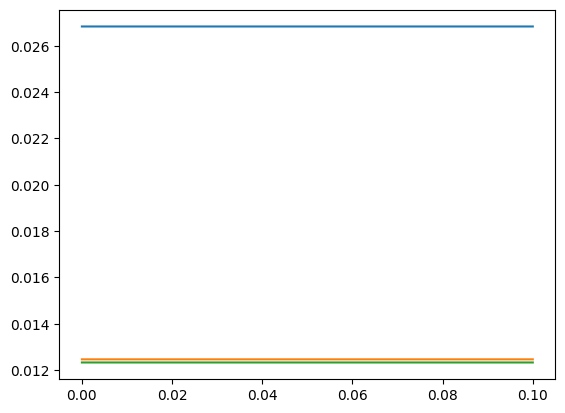

In [1380]:
plt.plot(time_steps, data['T1'])
plt.plot(time_steps, data['T2'])
plt.plot(time_steps, data['T10'])